# Measure: Fraction of the Clusters over 3 different states


In [117]:
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit, prange
from numba.typed import List
from collections import Counter


### Functions

In [118]:
# Local dynamics
@njit(parallel=False)
def fx(xold,yold,d):
    fxn=(xold**2)*(np.exp(yold-xold))+d
    return fxn
@njit(parallel=False)
def fy(xold,yold):
    fyn=a*(yold)-q*(xold)+c
    return fyn

#System evolution
@njit(parallel=False)
def xn(fxn, eps):
    xnew = (1-eps)*fxn + eps*np.mean(fxn)    
    return xnew

### Desynchronization Phase

In [119]:
# Parameters
N = 1000
b=200
T=50000
a=0.89
q=0.18
c=0.28

#Global Evolution 
def GCM(eps):
    initialx = np.random.uniform(1, 3, N)
    initialy = np.random.uniform(1, 4, N)
    x_s = np.zeros((T,N)) #to do transients
    y_s = np.zeros((T,N)) #to do transients
    heterogeniety = np.random.uniform(0.026, 0.03, N)
    x_s[0,:] = initialx
    y_s[0,:] = initialy
    for t in range(T-1):
        f_xj = fx(initialx, initialy, heterogeniety)
        f_yj = fy(initialx, initialy)
        x_s[t+1, :]= xn(f_xj, eps)
        y_s[t+1, :]= f_yj
        initialx = x_s[t+1, :]
        initialy = y_s[t+1, :]
    return x_s

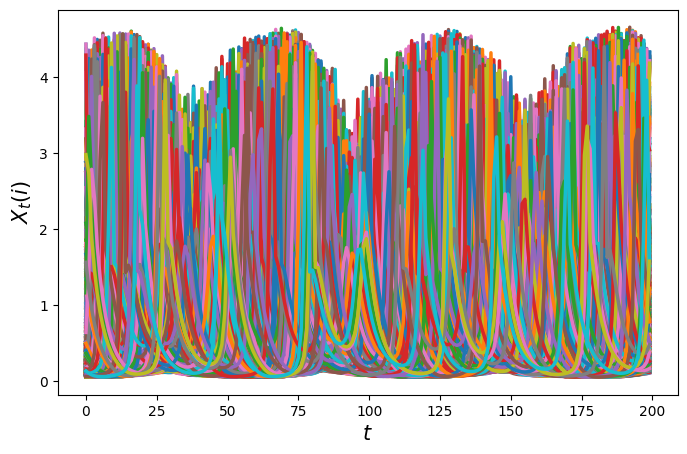

In [120]:
eps = 0.022
# Ploting time series
plt.figure(figsize=(8,5))
time = np.arange(0,int(b),1) 
states=GCM(eps)

S_matrix =np.zeros((b, N))
for tiempo in range(0,b):
    S_matrix[tiempo]=states[T-b+tiempo]

for ij in range(N):
    plt.plot(time, S_matrix[:,ij], linewidth=2.5)
plt.xlabel("$t$", fontsize=15)
plt.ylabel("$X_{t}(i)$", fontsize=15)
#filename = 'GP_Heterogeneity_Cuadratic_GCM_eps=0.4.png'
#plt.savefig(filename, dpi=300)
plt.show()

In [ ]:
#Clustering threshold
delta = 0.0001
p_t = np.zeros(b)

#Classificator
def Sigma(x):
    if x<0:    
        return 0
    if x>=0:
        return 1
for t in range(int(b)):
    Sum = []
    for i in range(N-1):
        xj = list(S_matrix[t]) #list with all nodes minus i
        xi = xj.pop(i) 
        dij = np.abs(np.subtract(xi, xj))
        SIG = dij - delta    
        Product = [] 
        for k in SIG:
            Product.append(Sigma(k))
        #print(len(Product))
        Sum.append(np.prod(Product))
    #print(Sum)
    p_t[t] = 1 - np.sum(Sum)/N
    #print(p_t)

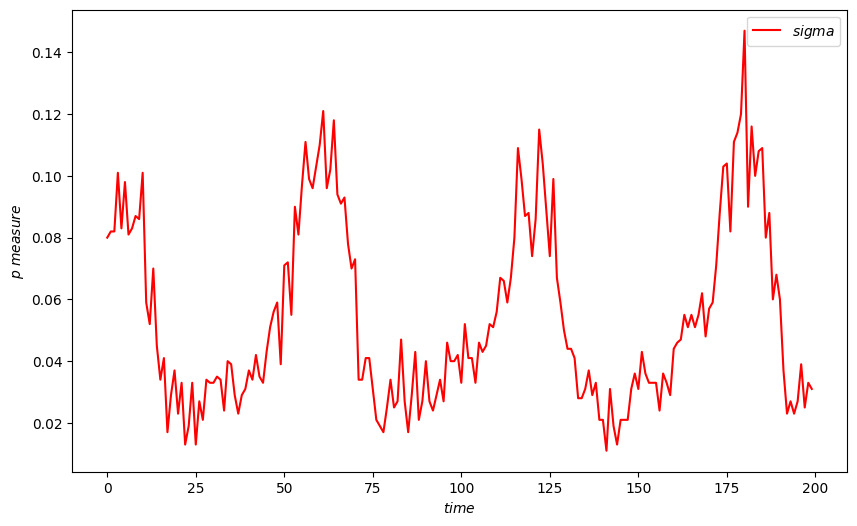

In [122]:
Pt_draw = p_t    
plt.figure(figsize=(10,6))
plt.plot(time, p_t,'r', label = r'$sigma$' )
plt.xlabel("$time$")
plt.ylabel("$p$ $measure$")
plt.legend()
plt.show()

### Griffiths Phase

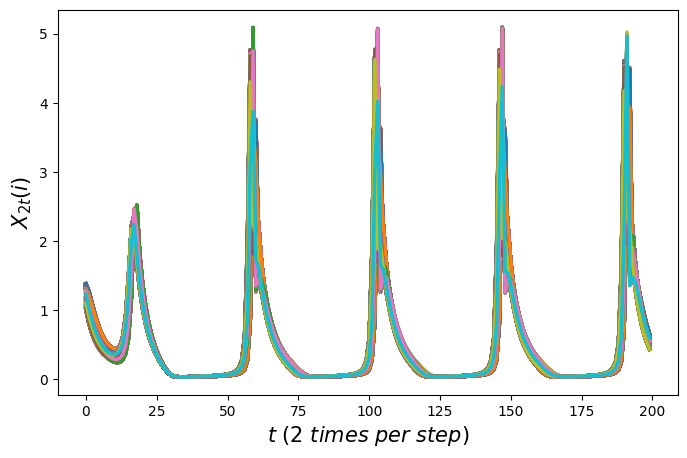

In [123]:
eps = 0.12
# Ploting time series
plt.figure(figsize=(8,5))

time = np.arange(0,int(b),1)
states=GCM(eps)
S_matrix =np.zeros((b, N))
for tiempo in range(0,b):
    S_matrix[tiempo]=states[T-b+tiempo]

for ij in range(N):
    plt.plot(time, S_matrix[:,ij], linewidth=2.5)
plt.xlabel("$t$ $(2$ $times$ $per$ $step)$", fontsize=15)
plt.ylabel("$X_{2t}(i)$", fontsize=15)
#filename = 'GP_Heterogeneity_Cuadratic_GCM_eps=0.4.png'
#plt.savefig(filename, dpi=300)
plt.show()

In [124]:
#Clustering parameter
delta = 0.0001

def Sigma(x):
    if x<0:    
        return 0
    if x>=0:
        return 1

#print(states)
p_t = np.zeros(b)
for t in range(int(b)):
    Sum = []
    for i in range(N-1):
        xj = list(S_matrix[t]) #list with all nodes minus i (len(100))
        xi = xj.pop(i) 
        dij = np.abs(np.subtract(xi, xj))
        SIG = dij - delta 
        Product = [] 
        for k in SIG:
            Product.append(Sigma(k))
        #print(len(Product))
        Sum.append(np.prod(Product))
    #print("suma")
    #print(Sum)
    p_t[t] = 1 - np.sum(Sum)/N

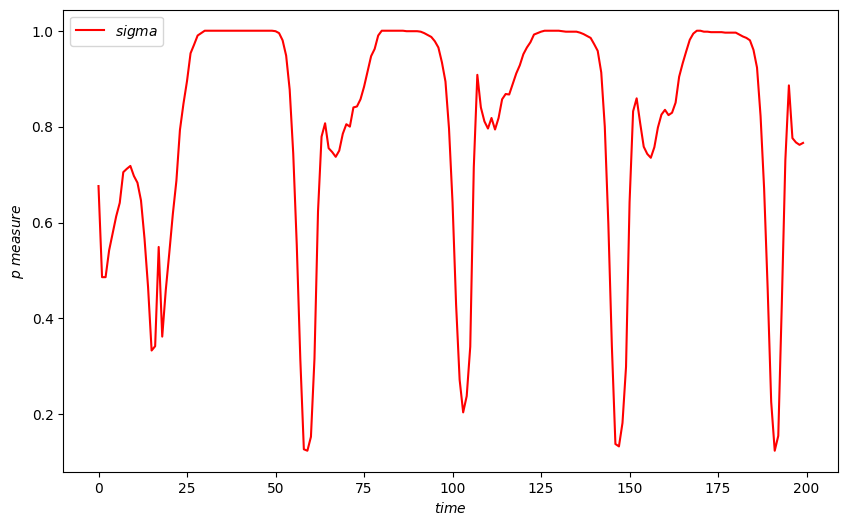

In [125]:
Pt_draw1 = p_t    

plt.figure(figsize=(10,6))
plt.plot(time, p_t,'r', label = r'$sigma$' )
plt.xlabel("$time$")
plt.ylabel("$p$ $measure$")
plt.legend()
plt.show()

### Synchronization Phase

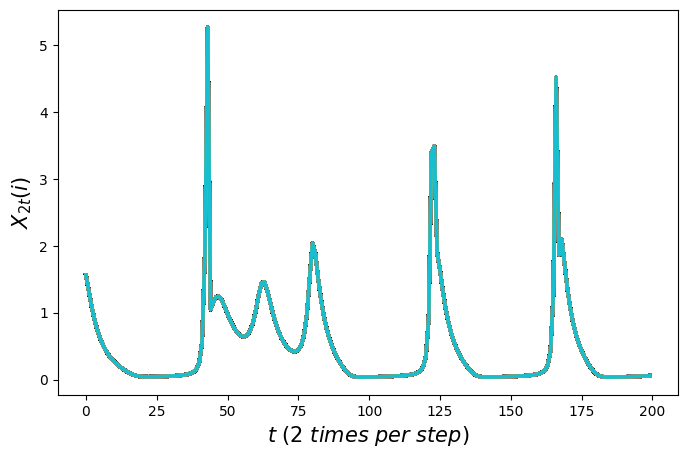

In [126]:
eps = 0.65
# Ploting time series
plt.figure(figsize=(8,5))

time = np.arange(0,int(b),1)
states=GCM(eps)
S_matrix =np.zeros((b, N))
for tiempo in range(0,b):
    S_matrix[tiempo]=states[T-b+tiempo]

for ij in range(N):
    plt.plot(time, S_matrix[:,ij], linewidth=2.5)
plt.xlabel("$t$ $(2$ $times$ $per$ $step)$", fontsize=15)
plt.ylabel("$X_{2t}(i)$", fontsize=15)
#filename = 'GP_Heterogeneity_Cuadratic_GCM_eps=0.4.png'
#plt.savefig(filename, dpi=300)
plt.show()

In [127]:
#Clustering parameter
delta = 0.0001

def Sigma(x):
    if x<0:    
        return 0
    if x>=0:
        return 1

#print(states)
p_t = np.zeros(b)
#print(p_t.shape)
for t in range(int(b)):
    Sum = []
    for i in range(N-1):
        xj = list(S_matrix[t]) 
        xi = xj.pop(i) 
        dij = np.abs(np.subtract(xi, xj))
        SIG = dij - delta 
        Product = [] 
        for k in SIG:
            Product.append(Sigma(k))
        Sum.append(np.prod(Product))
    #print("suma")
    #print(Sum)
    p_t[t] = 1 - np.sum(Sum)/N

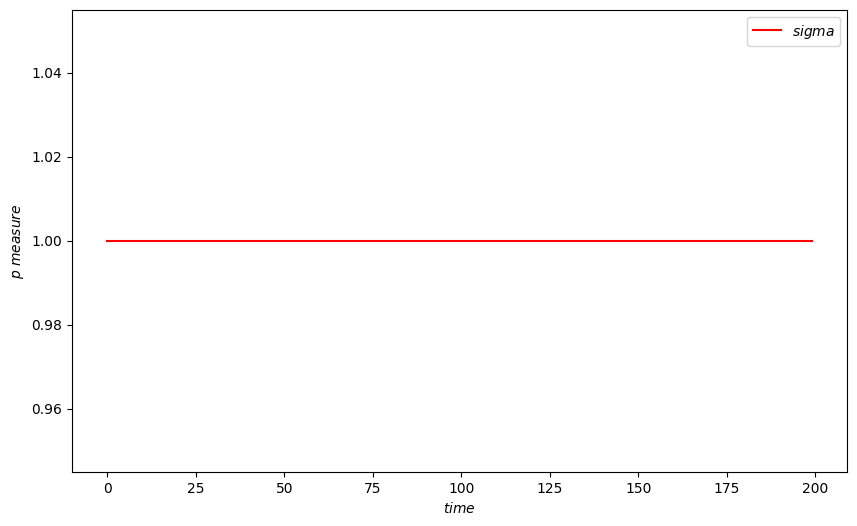

In [128]:
Pt_draw2 = p_t    

plt.figure(figsize=(10,6))
plt.plot(time, p_t,'r', label = r'$sigma$' )
plt.xlabel("$time$")
plt.ylabel("$p$ $measure$")
plt.legend()
plt.show()

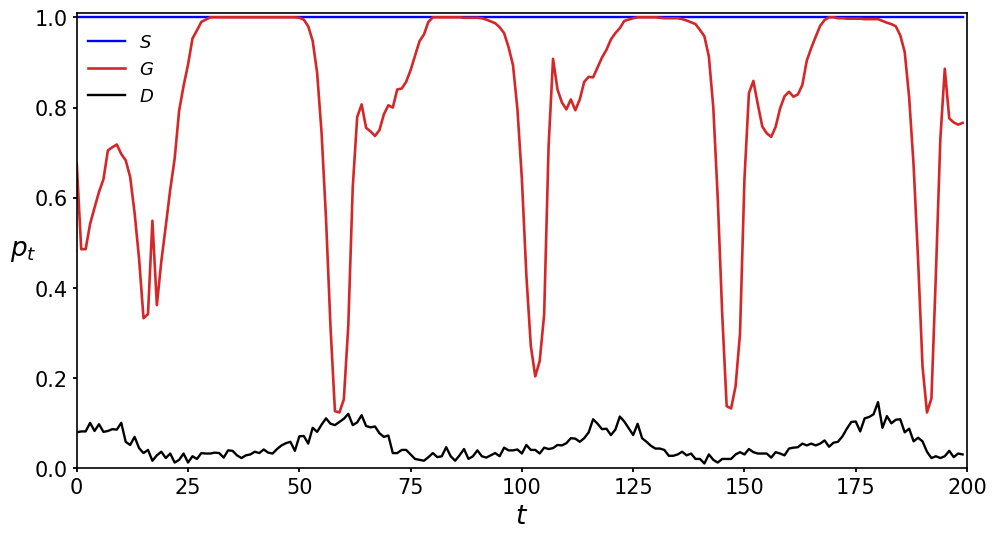

In [129]:
plt.figure(figsize=(10, 5.5))

plt.plot(time, Pt_draw2, "b", label=r'$S$', linewidth=1.7)
plt.plot(time, Pt_draw1, "#d62728", label=r'$G$', linewidth=1.9)
plt.plot(time, Pt_draw, "k", label=r'$D$', linewidth=1.7)

ax = plt.gca()

for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(1.2)
    ax.spines[axis].set_edgecolor('black')

ax.tick_params(axis='both', which='major',
               labelsize=15, width=1.3, length=3)

plt.xlabel(r"$t$", fontsize=19)
plt.ylabel(r"$p_t$", fontsize=19, rotation=0, labelpad=20)
ax.yaxis.set_label_coords(-0.06, 0.45)

plt.ylim(0, 1.01)
plt.xlim(0, 200)
plt.legend(loc='upper center',
           bbox_to_anchor=(0.05, 0.99),
           fontsize=13,
           frameon=False,
           edgecolor='black',
           framealpha=1)

plt.grid(False)
plt.tight_layout()

filename = 'Fig2_Fraction_of_Clusters.pdf'
plt.savefig(filename, format='pdf', dpi=300, bbox_inches="tight")
plt.show()
